# Install

In [2]:
!git clone https://github.com/shounendev/pytorch-CycleGAN-and-pix2pix.git

fatal: destination path 'pytorch-CycleGAN-and-pix2pix' already exists and is not an empty directory.


In [3]:
import os
os.chdir('pytorch-CycleGAN-and-pix2pix/')

In [4]:
!pip install dominate wandb matplotlib torchvision litert_torch

  Using cached dominate-2.9.1-py2.py3-none-any.whl.metadata (13 kB)
  Using cached wandb-0.25.0-py3-none-manylinux_2_28_x86_64.whl.metadata (12 kB)
  Using cached matplotlib-3.10.8-cp310-cp310-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (52 kB)
  Using cached torchvision-0.25.0-cp310-cp310-manylinux_2_28_x86_64.whl.metadata (5.4 kB)
  Using cached litert_torch-0.8.0-py3-none-any.whl.metadata (2.5 kB)
  Using cached click-8.3.1-py3-none-any.whl.metadata (2.6 kB)
  Using cached gitpython-3.1.46-py3-none-any.whl.metadata (13 kB)
  Using cached protobuf-6.33.5-cp39-abi3-manylinux2014_x86_64.whl.metadata (593 bytes)
  Using cached pydantic-2.12.5-py3-none-any.whl.metadata (90 kB)
  Using cached sentry_sdk-2.54.0-py2.py3-none-any.whl.metadata (10 kB)
  Using cached annotated_types-0.7.0-py3-none-any.whl.metadata (15 kB)
  Using cached pydantic_core-2.41.5-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (7.3 kB)
  Using cached typing_inspection-0.4.2-py3-none-a

# Prepare training data 

Before continuing, make sure you have generated a dataset using the scripts in the `DataGen` directory. 

In [5]:
DATA_PATH = "../../DataGen/output/"

In [6]:
!ls {DATA_PATH}

temp  test  train  val


**Resizing images to 256x256. If you want to train the upscaling model, referece the backup folder in the training step**

In [7]:
!python util/resize_pngs.py {DATA_PATH} --clean

Error: backup directory '/run/media/p_wiggin/45914096-d5a0-44bb-8d1c-8faa117a3407/PROJECTS/2D-Fluid-Enhancement/clean_test/DataGen/output_backup' already exists.


# Training

-   `python train.py --dataroot {DATA_PATH} --name water_pix2pix --model pix2pix --direction BtoA`

Change `--name` model's name. Use `--gpu_ids 0,1,..` to train on multiple GPUs and `--batch_size` to change the batch size. Add `--direction BtoA` if you want to train a model to transfrom from class B to A.

#### Upscaling:

`--netG unet_256_up` — Use the upscaling-aware U-Net generator (instead of the default unet_256).

`--num_upscale_layers` N — Number of 2x upsampling layers appended after the U-Net. Each layer doubles the resolution:
- 1 = 2x upscale (256→512)
- 2 = 4x upscale (256→1024)

Make sure to also adjust netG later in the testing command

In [19]:
!python train.py --dataroot {DATA_PATH} --name water_pix2pix --model pix2pix --direction AtoB --netG unet_256 --dataset_mode paired --preprocess none --no_flip --batch_size 1

----------------- Options ---------------
               batch_size: 1                             
                    beta1: 0.5                           
          checkpoints_dir: ./checkpoints                 
           continue_train: False                         
                crop_size: 256                           
                 dataroot: ../../DataGen/output/         	[default: None]
             dataset_mode: paired                        	[default: aligned]
                direction: AtoB                          
             display_freq: 400                           
          display_winsize: 256                           
                    epoch: latest                        
              epoch_count: 1                             
                 gan_mode: vanilla                       
                init_gain: 0.02                          
                init_type: normal                        
                 input_nc: 3                         

# Testing

-   `python test.py --dataroot ./datasets/facades --direction BtoA --model pix2pix --name facades_pix2pix`

Change the `--dataroot`, `--name`, and `--direction` to be consistent with your trained model's configuration and how you want to transform images.

In [20]:
!ls checkpoints/

water_pix2pix


In [21]:
!python test.py --dataroot {DATA_PATH} --direction AtoB --model pix2pix --name water_pix2pix --netG unet_256 --dataset_mode paired --preprocess none --no_flip

----------------- Options ---------------
             aspect_ratio: 1.0                           
               batch_size: 1                             
          checkpoints_dir: ./checkpoints                 
                crop_size: 256                           
                 dataroot: ../../DataGen/output/         	[default: None]
             dataset_mode: paired                        	[default: aligned]
                direction: AtoB                          
          display_winsize: 256                           
                    epoch: latest                        
                     eval: False                         
                init_gain: 0.02                          
                init_type: normal                        
                 input_nc: 3                             
                  isTrain: False                         	[default: None]
                load_iter: 0                             	[default: 0]
                load_siz

# Visualize

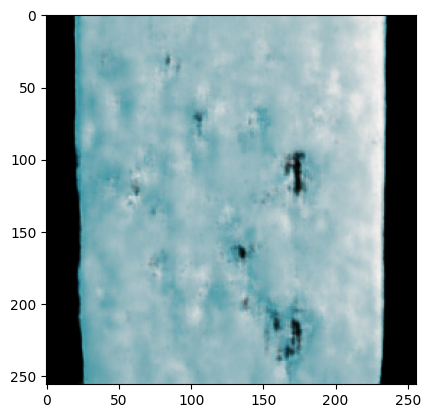

In [30]:
import matplotlib.pyplot as plt

img = plt.imread('./results/water_pix2pix/test_latest/images/0001_fake_B.png')
plt.imshow(img)

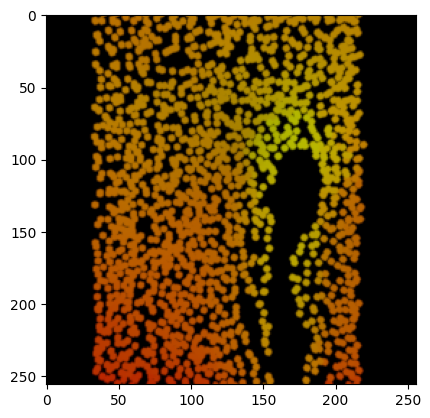

In [31]:
img = plt.imread('./results/water_pix2pix/test_latest/images/0001_real_A.png')
plt.imshow(img)

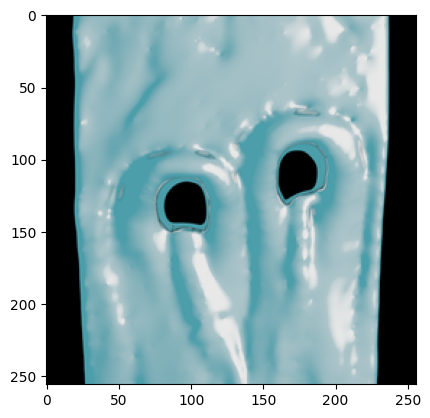

In [32]:
img = plt.imread('./results/water_pix2pix/test_latest/images/0001_real_B.png')
plt.imshow(img)

# Conversion

In [18]:
!python ./scripts/convert_to_tflite.py -o ./converted/pix2pix_water.tflite --checkpoint ./checkpoints/water_pix2pix/latest_net_G.pth

I0000 00:00:1772592480.589059  416711 cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
Skipping import of cpp extensions due to incompatible torch version 2.9.1+cu128 for torchao version 0.16.0             Please see https://github.com/pytorch/ao/issues/2919 for more info
/home/p_wiggin/.local/share/mise/installs/python/3.10.20/lib/python3.10/site-packages/torch/distributed/distributed_c10d.py:351: UserWarning: Device capability of jax unspecified, assuming `cpu` and `cuda`. Please specify it via the `devices` argument of `register_backend`.
  warnings.warn(
Converting with quantization='none' ...
W0000 00:00:1772592489.333993  416711 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1772592489.334026  416711 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control

# Running the model
To run the converted model in the browser, place it in `../static` and run `npm run dev` form the project root